In [1]:
import numpy as np
import pandas as pd

import scarf

scarf.configure_output(level="WARNING", progress=False)

counts = scarf.cytebase.connect("scarf_docs").download(
    "tenx_5K_pbmc_rnaseq/data.h5",
    destination="scarf_datasets",
)[0]

store = counts.with_name("data.zarr")
reader = scarf.CrH5Reader(str(counts))
scarf.CrToZarr(
    reader,
    zarr_loc=str(store),
).dump()

ds = scarf.DataStore(
    str(store),
    nthreads=4,
    min_features_per_cell=10,
)

Downloading bucket files: 18098007 / 18098007 complete

Downloading bytes: 18098007 / 18098007 complete

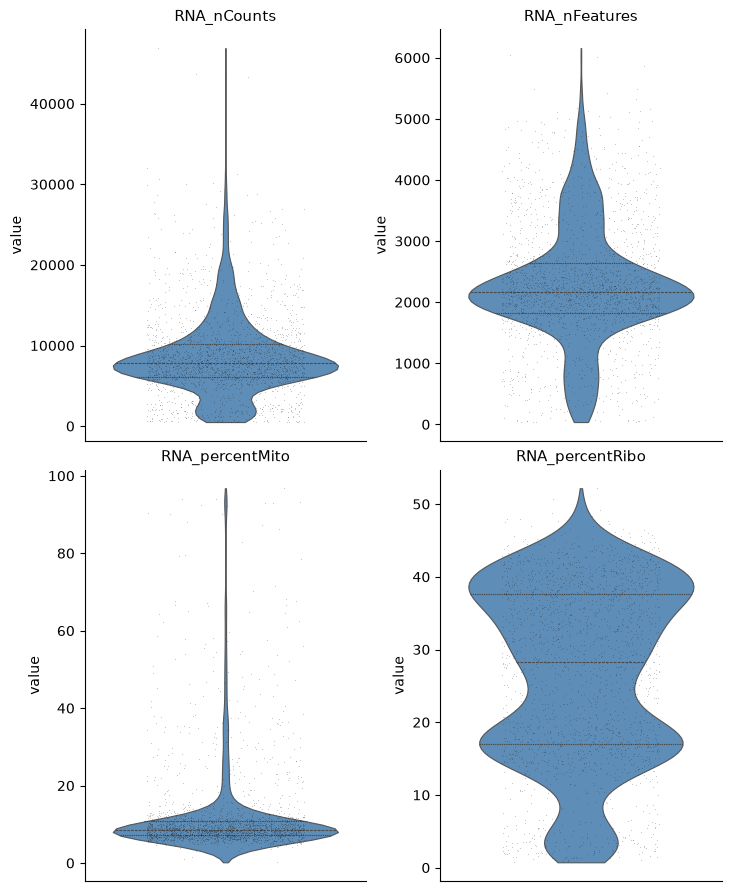

In [2]:
qc_cols = [
    c
    for c in ("RNA_nCounts", "RNA_nFeatures", "RNA_percentMito", "RNA_percentRibo")
    if c in ds.cells.columns
]
qc_cell_selection = ds.snapshot_cell_selection("I")
ds.plots.distribution(
    keys=qc_cols,
    cell_selection=qc_cell_selection,
    kind="violin",
    max_points=2000,
)

In [3]:
n_before = int(ds.cells.fetch_all("I").sum())
manual_filter = {
    "attrs": ["RNA_nCounts", "RNA_nFeatures", "RNA_percentMito"],
    "highs": [15000, 4000, 15],
    "lows": [1000, 500, 0],
}
manual_selection = ds.filter_cells(**manual_filter)
manual_mask = np.asarray(ds.load_artifact(manual_selection)["values"][:], dtype=bool)
print(f"Cells in input selection: {n_before}")
print(f"Cells in filtered selection: {int(manual_mask.sum())}")
pd.DataFrame({key: ds.cells.fetch_all(key)[manual_mask] for key in qc_cols}).describe()

Cells in input selection: 5025
Cells in filtered selection: 3940


,RNA_nCounts,RNA_nFeatures,RNA_percentMito,RNA_percentRibo
count,3940.000000,3940.000000,3940.000000,3940.000000
mean,8245.728934,2270.309898,8.575001,30.207449
std,2468.784922,541.559187,2.110144,10.202904
min,1057.000000,512.000000,0.188857,0.737101
25%,6562.000000,1922.000000,7.047202,20.122006
50%,7882.500000,2186.500000,8.364386,32.484297
75%,9606.750000,2527.000000,9.872131,38.770864
max,14992.000000,3930.000000,14.998783,52.181596


In [4]:
automatic_selection = ds.auto_filter_cells(cell_selection=manual_selection)
automatic_mask = np.asarray(
    ds.load_artifact(automatic_selection)["values"][:],
    dtype=bool,
)
print(f"Cells after automatic refinement: {int(automatic_mask.sum())}")

Cells after automatic refinement: 3595


In [5]:
feature_names = ds.RNA.feats.fetch_all("names").astype(str)
stress_features = ds.set_feature_selection(
    from_assay="RNA",
    mask=np.char.startswith(feature_names, "HSP"),
)
stress_percentage = ds.run_feature_percentage(
    manual_selection,
    stress_features,
)
stress_values = np.asarray(ds.load_artifact(stress_percentage)["values"][:])
pd.Series(stress_values, name="percent stress features").describe()

count    3940.000000
mean        0.328357
std         0.130553
min         0.000000
25%         0.238518
50%         0.309843
75%         0.395623
max         1.531394
Name: percent stress features, dtype: float64

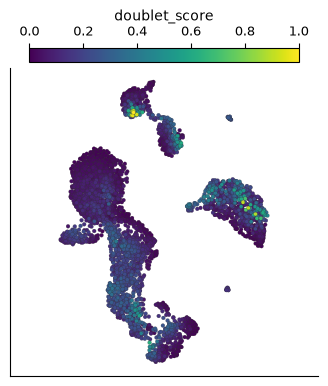

In [6]:
doublet_run = ds.pipeline.run(
    filtering={"method": "manual", **manual_filter},
    hvg_count=500,
    pca_dims=15,
    leiden={"partitions": [0.5]},
    cell_cycle=False,
    paris=False,
    doublets=True,
    markers=False,
)
doublets = doublet_run["doublets"]
scores = np.asarray(doublet_run.cells.fetch("doublet_score"))
ds.plots.embedding(
    run=doublet_run,
    color_by="doublet_score",
    sort_values=True,
)

<Axes: ylabel='Frequency'>

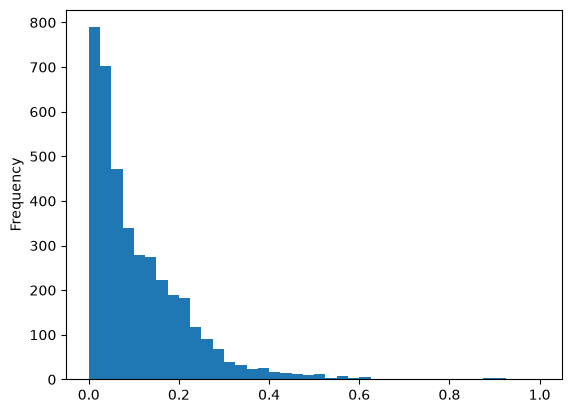

In [7]:
pd.Series(scores, name="doublet_score").plot(kind="hist", bins=40)

In [8]:
scores_series = pd.Series(scores, name="doublet_score")
print(scores_series.describe())
doublet_threshold = float(scores_series.quantile(0.95))
print(f"Doublet threshold (95th percentile): {doublet_threshold:.4f}")
print(f"Cells above threshold: {int((scores > doublet_threshold).sum())}")

count    3940.000000
mean        0.110904
std         0.110779
min         0.000000
25%         0.030497
50%         0.075340
75%         0.161276
max         1.000000
Name: doublet_score, dtype: float64
Doublet threshold (95th percentile): 0.3109
Cells above threshold: 197


In [9]:
doublet_filtered = ds.select_cells(
    doublets,
    high=doublet_threshold,
    keep_bounds=True,
)
int(np.asarray(ds.load_artifact(doublet_filtered)["values"][:]).sum())

3743